In [1]:
import ast
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\bryan\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


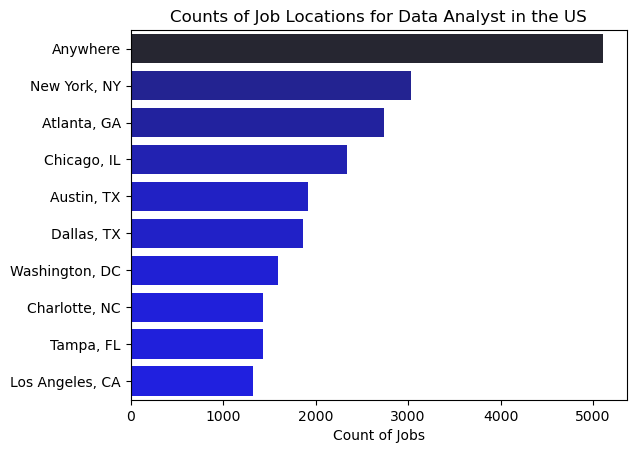

In [6]:
df_da_us= df[(df['job_title_short'] == 'Data Analyst') &(df['job_country'] == 'United States')]
df_plot= df_da_us['job_location'].value_counts().head(10).to_frame()
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
plt.title('Counts of Job Locations for Data Analyst in the US')
plt.ylabel('')
plt.xlabel('Count of Jobs')
plt.show()


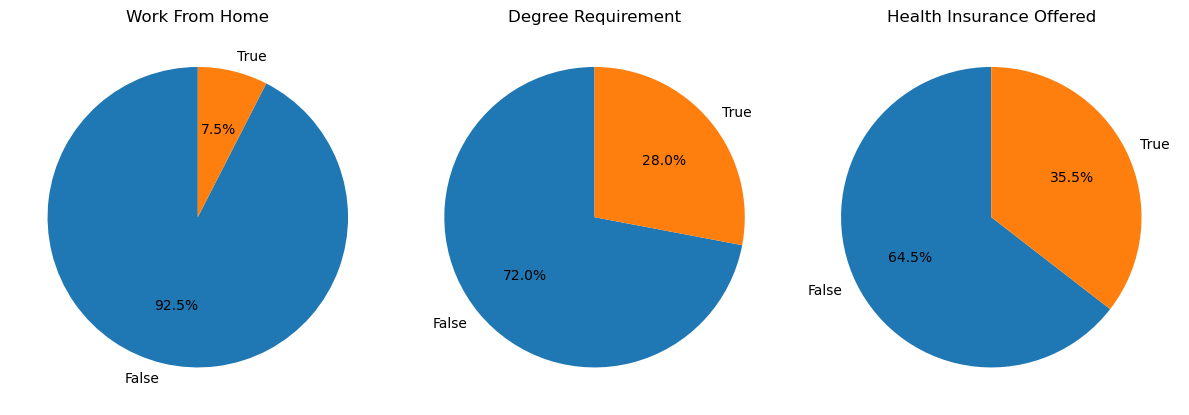

In [12]:
fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12,5))
dict_column ={
'job_work_from_home': 'Work From Home',
'job_no_degree_mention': 'Degree Requirement',
'job_health_insurance': 'Health Insurance Offered'
}
for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_da_us[column].value_counts(), startangle=90, autopct='%1.1f%%', labels=['False','True'])
    ax[i].set_title(title)
fig.tight_layout()



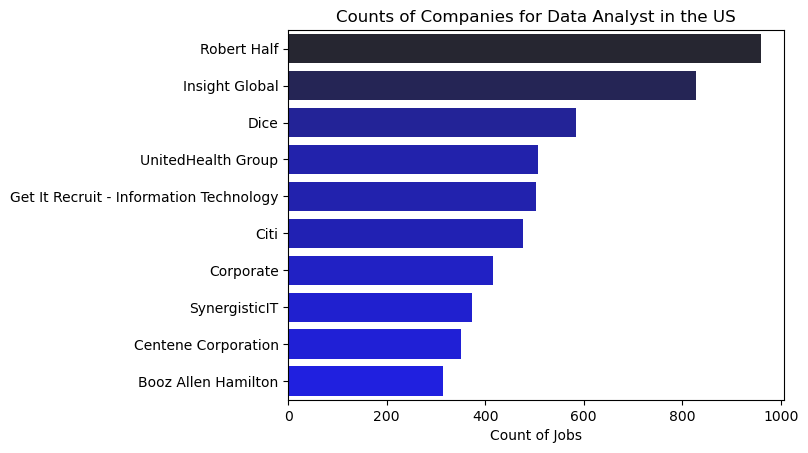

In [13]:
df_plot= df_da_us['company_name'].value_counts().head(10).to_frame()
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
plt.title('Counts of Companies for Data Analyst in the US')
plt.ylabel('')
plt.xlabel('Count of Jobs')
plt.show()